# 📅🤖 Week 4 — Your First Machine Learning Model
**SOC · Stock Trend Predictor**

> *Week 3 ended with a clean, ML-ready dataset — 8 features and a Target column, saved and ready. This week we use it to build your first machine learning model.*

## What We're Doing This Week

| Section | Topic |
|---|---|
| **1** | What is Machine Learning? (concepts first) |
| **2** | Loading the dataset from Week 3 |
| **3** | Splitting data into Train and Test sets |
| **4** | Your first model — Logistic Regression |
| **5** | Your second model — Decision Tree |
| **6** | Evaluating models properly |
| **7** | Overfitting vs Underfitting |
| **8** | Data Leakage — one final warning |
| **9** | Week 4 Assignment |

## Learning Objectives

By the end of this week you will be able to:
- Explain what machine learning is and how a model learns
- Split a time series dataset correctly into train and test sets
- Train a Logistic Regression and a Decision Tree classifier
- Read and interpret a confusion matrix
- Explain accuracy, precision, and recall in plain English
- Recognise overfitting and underfitting in a model


---
## 1 · What Is Machine Learning?

Before writing a single line of ML code, let's make sure the concept is crystal clear.

### The One-Sentence Definition

> Machine learning is the process of **showing a computer many examples** so that it learns to **recognise patterns** and make predictions on new data it has never seen before.

### A Simple Analogy

Imagine teaching a child to recognise dogs.
You don't write a rulebook that says: *'if it has four legs AND fur AND barks, then it's a dog.'*
Instead, you show the child hundreds of photos: *'this is a dog, this is not a dog.'*
After enough examples, the child figures out the pattern on their own.

That's exactly what we're doing — except instead of dogs, we're showing the model stock data, and instead of 'dog or not', we're asking 'up or down?'

### What Is a Model?

A model is just a **mathematical function** that maps inputs to outputs.

```
Input (features) → [ Model ] → Output (prediction)
```

In our project:
- **Input:** 8 features (Daily_Return, MA5_to_MA20, Price_to_MA20, etc.)
- **Output:** 1 = price goes Up tomorrow, 0 = price goes Down

### How Does a Model Learn?

1. You give it a bunch of rows where you already know the answer (your training data)
2. It makes a guess for each row
3. It compares its guess to the real answer
4. It adjusts itself to make fewer mistakes
5. Repeat thousands of times until it stops improving

This process is called **training** or **fitting** the model.

### Features vs Target — a Quick Recap

| Term | What it is | In our project |
|---|---|---|
| **Features** | The inputs the model uses to make its guess | Daily_Return, MA5_to_MA20, Volatility_5d, etc. |
| **Target** | The correct answer we're training the model to predict | 1 (Up) or 0 (Down) |

### Classification vs Regression

There are two main types of ML prediction problems:

| Type | Output | Example |
|---|---|---|
| **Classification** | A category / label | Up or Down? Spam or Not Spam? |
| **Regression** | A continuous number | What will the exact price be? |

> Our project is a **classification** problem — we predict one of two categories: Up (1) or Down (0).
> Predicting the exact future price would be regression, and it's much harder. We're keeping it simple.


---
## 2 · Loading the Dataset from Week 3

We start exactly where Week 3 ended — loading the ML-ready CSV you saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the feature dataset from Week 3
df = pd.read_csv(
    'data/processed/AAPL_features.csv',
    index_col='Date',
    parse_dates=True
)

print('Shape:', df.shape)
print()
print(df.head())


Shape: (482, 9)

            Daily_Return         MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                            
2024-06-21     -0.010445  210.302271     1.059428       1.036284    -0.021513   
2024-06-24      0.003133  209.439734     1.049511       1.034041    -0.010445   
2024-06-25      0.004468  207.932791     1.037042       1.033759     0.003133   
2024-06-26      0.019993  207.726581     1.030090       1.048398     0.004468   
2024-06-27      0.003986  208.602988     1.028417       1.046453     0.019993   

            Lag2_Return  Volatility_5d  Volume_Change  Target  
Date                                                           
2024-06-21    -0.010985       0.015399       1.806059       1  
2024-06-24    -0.021513       0.015876      -0.666148       1  
2024-06-25    -0.010445       0.010869      -0.311882       1  
2024-06-26     0.003133       0.015792       0.191963       1  
2024-06-27     0.004468       0

> 💡 **If you get a FileNotFoundError**, it means Week 3's notebook wasn't run yet. Go back and run it first — it saves the CSV that we load here.


In [2]:
# Define our features and target — same list from Week 3
feature_cols = [
    'Daily_Return',
    'MA5',
    'MA5_to_MA20',
    'Price_to_MA20',
    'Lag1_Return',
    'Lag2_Return',
    'Volatility_5d',
    'Volume_Change'
]

X = df[feature_cols]   # features — the inputs
y = df['Target']       # target  — what we predict

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('Target distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))


X shape: (482, 8)
y shape: (482,)

Target distribution:
Target
1    266
0    216
Name: count, dtype: int64
Target
1    0.552
0    0.448
Name: proportion, dtype: float64


---
## 3 · Splitting Data into Train and Test Sets

### Why Do We Need a Split?

Imagine you gave students the exam questions a week before the test, let them memorise the answers, and then used the same questions as the actual test.
They'd all score 100% — but that tells you nothing about whether they actually understand the material.

The same problem applies to ML models. If you train and test on the same data, the model just memorises the answers instead of learning patterns. You'd see 95% accuracy — then the model fails completely on real future data.

The solution: **train on some data, test on different data the model has never seen.**

### Why Can't We Shuffle? (Time Series Rule)

> ⚠️ **This is the most important rule for stock data.**

With normal data (like house prices), you can randomly shuffle rows before splitting.
With time series data like stock prices, **you cannot.**

Here's why: if you shuffle and split randomly, your training set might include data from December 2024, and your test set might include data from January 2023.
That means the model is trained on the **future** and tested on the **past** — a completely unrealistic scenario.

**Always split time series data by time: train on early dates, test on later dates.**

```
Timeline: ──────────────────────────────────────────────────▶
          [  Training Data (80%)   ] [ Test Data (20%) ]
          Jan 2023 ──────────────── Sep 2024 ──────── Dec 2024
```


In [3]:
# We split 80% for training, 20% for testing
# The split must respect time order — no shuffling

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f'Training rows : {len(X_train)}')
print(f'Test rows     : {len(X_test)}')
print()
print(f'Training period: {X_train.index[0].date()} to {X_train.index[-1].date()}')
print(f'Test period    : {X_test.index[0].date()}  to {X_test.index[-1].date()}')


Training rows : 385
Test rows     : 97

Training period: 2024-06-21 to 2026-01-02
Test period    : 2026-01-05  to 2026-05-22


> 💡 Blue = what the model learns from. Red = what the model is tested on.
> The model will only ever see the red section for the first time during evaluation — just like a real deployment.


## 4 · Training and Evaluating Both Models

Every sklearn model follows the same three-step workflow:

```
Step 1 — model.fit(X_train, y_train)      ← learn from training data
Step 2 — predictions = model.predict(X_test) ← make predictions on test data
Step 3 — accuracy_score(y_test, predictions) ← how well did it do?
```

This workflow is the same for every model you'll ever train — Logistic Regression, Decision Tree, Random Forest, Neural Network. Learn this pattern and it will serve you for years.

---
## · Logistic Regression — The Intuition

### What it is

Despite the name, Logistic Regression is a **classification** model.
The word 'regression' refers to how it works internally, not what it predicts.

### The core idea — a score that becomes a probability

Logistic Regression does something very simple:

1. It gives each feature a **weight** (a number that represents its importance)
2. It multiplies each feature value by its weight and adds them all up → this gives a **score**
3. It passes that score through a special function (called the sigmoid function) that squashes any number into a value between 0 and 1
4. That value is a **probability** — e.g. 0.73 means '73% chance the stock goes up'
5. If the probability is above 0.5 → predict Up. Below 0.5 → predict Down.

```
Score = (w1 × Daily_Return) + (w2 × MA5_to_MA20) + (w3 × Volatility_5d) + ...
         ↓
Probability = sigmoid(Score)   ← always between 0 and 1
         ↓
Prediction = 1 if Probability > 0.5 else 0
```

### What does 'learning' mean for Logistic Regression?

Learning = finding the best set of weights.

The model starts with random weights, makes predictions, sees how wrong it is, and adjusts the weights to reduce its mistakes. After many rounds of this, the weights stabilise at values that work well.

### Why start with Logistic Regression?

- Very fast to train
- Easy to understand what it's doing
- Often surprisingly effective
- It's the standard **baseline** — if a fancier model can't beat logistic regression, something is wrong with the fancier model

### A visual example

Imagine we only had 2 features. Logistic Regression draws a straight line:

```
Feature B
    │         ●  ●   ← Up days
    │      ●
    │  ────────────── ← decision boundary (the line)
    │○       ○
    │  ○  ○          ← Down days
    └────────────── Feature A
```

Everything above the line → predict Up.
Everything below the line → predict Down.
With 8 features, it's the same idea but in 8 dimensions (impossible to visualise, but same concept).

### 📚 Resources — read/watch before the code
- 🎥 [Logistic Regression clearly explained — StatQuest](https://www.youtube.com/watch?v=yIYKR4sgzI8) *(watch this fully — 19 mins, worth every second)*
- 📖 [Logistic Regression explained simply — Towards Data Science](https://towardsdatascience.com/logistic-regression-explained-9ee73cede081)



In [25]:
from sklearn.linear_model import LogisticRegression

# Step 1: Create the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Train it — 'fit' means 'learn from this data'
lr_model.fit(X_train, y_train)

print('Model trained!')



Model trained!


In [26]:
# Step 3: Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Peek at the first 10 predictions vs the real answers
comparison = pd.DataFrame({
    'Actual':     y_test.values[:10],
    'Predicted':  lr_predictions[:10]
}, index=y_test.index[:10])

print('First 10 predictions vs actual:')
print(comparison)


First 10 predictions vs actual:
            Actual  Predicted
Date                         
2026-01-05       0          0
2026-01-06       0          0
2026-01-07       0          0
2026-01-08       1          0
2026-01-09       1          0
2026-01-12       1          0
2026-01-13       0          0
2026-01-14       0          0
2026-01-15       0          0
2026-01-16       0          1


In [27]:
# Step 4: Evaluate accuracy
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f'Logistic Regression Accuracy: {lr_accuracy:.2%}')

# Also check training accuracy (useful for detecting overfitting later)
lr_train_accuracy = accuracy_score(y_train, lr_model.predict(X_train))
print(f'Training Accuracy           : {lr_train_accuracy:.2%}')


Logistic Regression Accuracy: 52.58%
Training Accuracy           : 55.84%


### What Does Accuracy Mean?

Accuracy = the percentage of predictions that were correct.

```
Accuracy = Correct predictions / Total predictions
```

For example: if the model predicted 100 days and got 53 right → accuracy = 53%.

> 💡 **Is 53% good?** For stock direction prediction, yes. Random guessing gives 50%. A consistent 53–56% edge can be useful in practice. Very high accuracy often indicates data leakage, overfitting, or a problem in the experimental setup.


---
## 5 · Decision Trees — The Intuition

### What it is

A Decision Tree learns a series of yes/no questions about your features.
It's exactly like a flowchart — at each step, it asks one question and branches left or right.

### A real example

Imagine the tree learned these rules from our stock data:

```
                 ┌─────────────────────────────┐
                 │  Is MA5_to_MA20 > 1.01?      │
                 └─────────────────────────────┘
                        /              \
                      YES               NO
                      /                  \
        ┌─────────────────────┐     ┌─────────────────────┐
        │ Is Daily_Return > 0? │     │ Is Volatility < 0.01?│
        └─────────────────────┘     └─────────────────────┘
            /         \                  /         \
          YES          NO              YES          NO
           ↓            ↓              ↓            ↓
        Predict       Predict       Predict       Predict
          UP           DOWN          DOWN           UP
```

The tree asks one question at a time, following the branches until it reaches a final prediction.

### What does 'learning' mean for a Decision Tree?

The model figures out:
1. **Which feature to ask about first** (the one that best separates Up and Down days)
2. **What threshold to use** (e.g. '> 1.01' vs '> 0.98')
3. **How deep to go** — more questions = more complex rules

### The depth problem

If we let the tree ask unlimited questions, it will eventually learn a rule for every single training day.
It will get 100% accuracy on training data — but fail on new data.

This is called **overfitting**, and we'll see it live in Section 9.
We control it by setting a **max_depth** — limiting how many questions the tree can ask.

### Why learn Decision Trees?

- Very easy to visualise and interpret — you can literally see the rules it learned
- No maths knowledge required to understand the output
- Forms the building block for more powerful models (Random Forest in Week 5)

### 📚 Resources — read/watch before the code
- 🎥 [Decision Tree classification — Normalized Nerd](https://www.youtube.com/watch?v=ZVR2Way4nwQ)
- 🎥 [Decision Trees clearly explained — StatQuest](https://www.youtube.com/watch?v=_L39rN6gz7Y) 

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# max_depth limits how many splits the tree can make, tree can ask at most 4 questions before making a prediction
# Without a limit, the tree will memorise the training data perfectly (overfitting)
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_train_accuracy = accuracy_score(y_train, dt_model.predict(X_train))

print(f'Decision Tree Test Accuracy : {dt_accuracy:.2%}')
print(f'Decision Tree Train Accuracy: {dt_train_accuracy:.2%}')


Decision Tree Test Accuracy : 47.42%
Decision Tree Train Accuracy: 63.64%


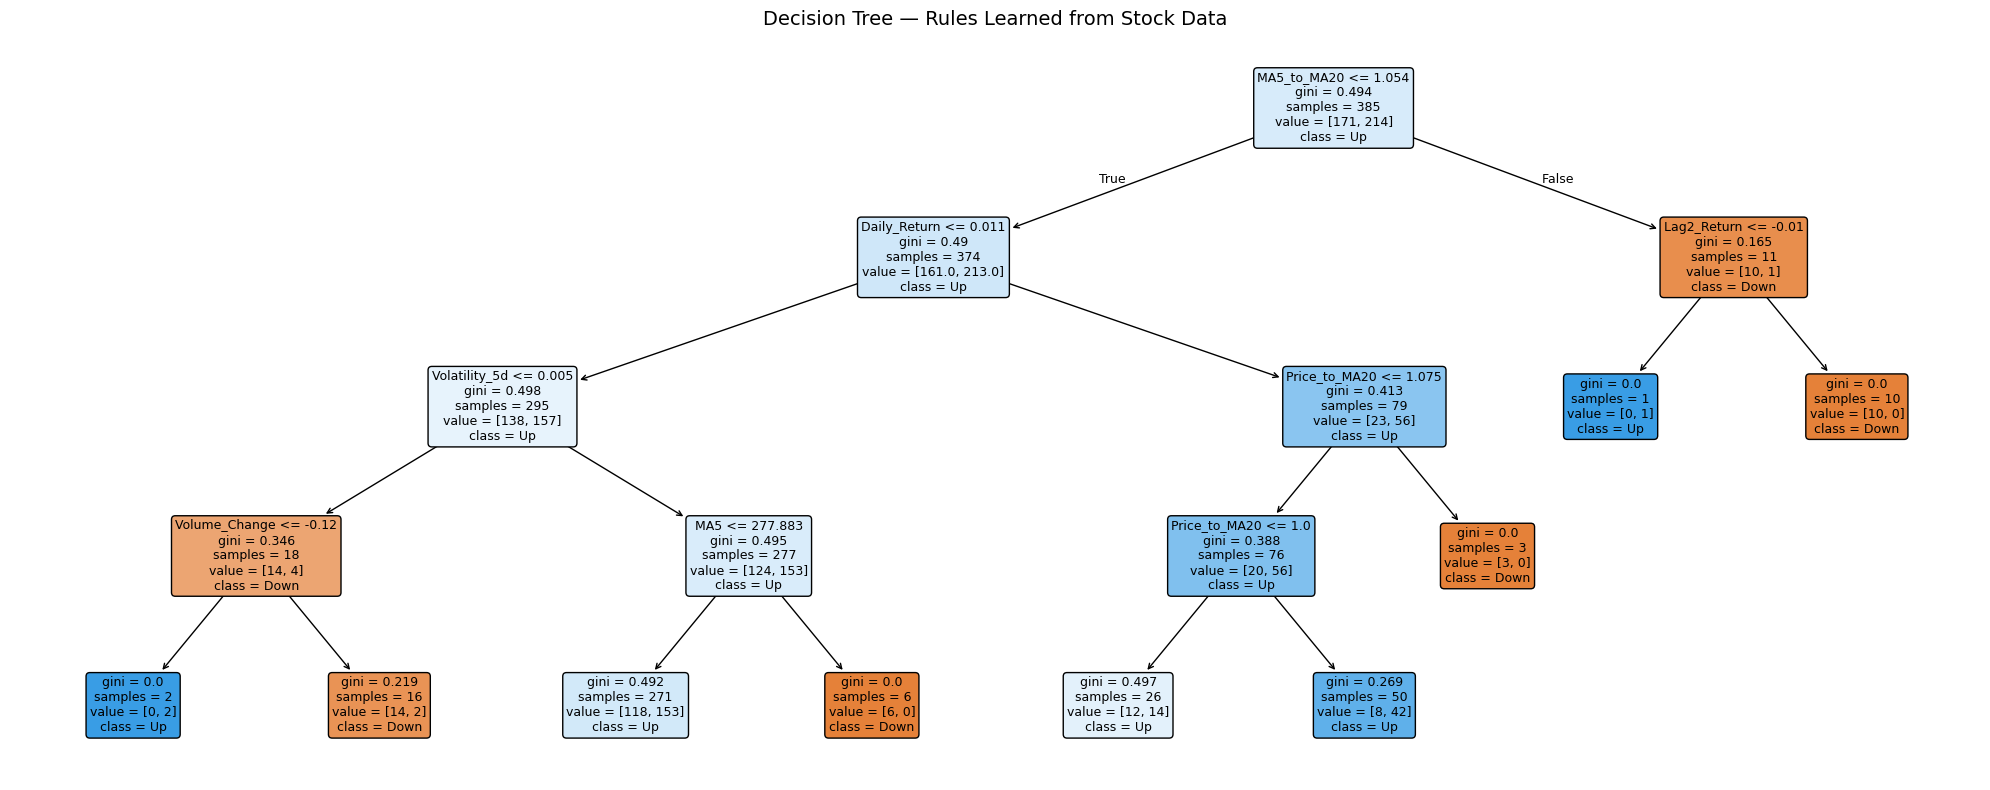

In [46]:
# Visualize the Decision Tree — see the rules it learned
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Down', 'Up'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Rules Learned from Stock Data', fontsize=14)
plt.tight_layout()
plt.show()


> 💡 **Reading the tree:** Each box (node) shows the feature and threshold used to split. Blue boxes lean toward 'Down', orange boxes lean toward 'Up'. The darker the colour, the more confident the prediction.

### 🎯 Try it yourself
Look at the tree visualization above. What is the very first feature the tree splits on? Does that make intuitive sense for stock prediction? Write your observation below.


In [47]:
# Your observation:


---
## 6 · Evaluating Models Properly

Accuracy alone doesn't tell the full story. Let's go deeper.

### The Confusion Matrix

A confusion matrix shows you exactly where your model is making mistakes.

```
                    Predicted: Down    Predicted: Up
Actual: Down     [  True Negative  ]  [ False Positive ]
Actual: Up       [ False Negative  ]  [  True Positive ]
```

- **True Positive (TP):** Model said Up, stock went Up ✅
- **True Negative (TN):** Model said Down, stock went Down ✅
- **False Positive (FP):** Model said Up, stock went Down ❌ (you bought when you shouldn't have)
- **False Negative (FN):** Model said Down, stock went Up ❌ (you missed a good day)

In finance, False Positives are expensive — you bought stock that then fell.


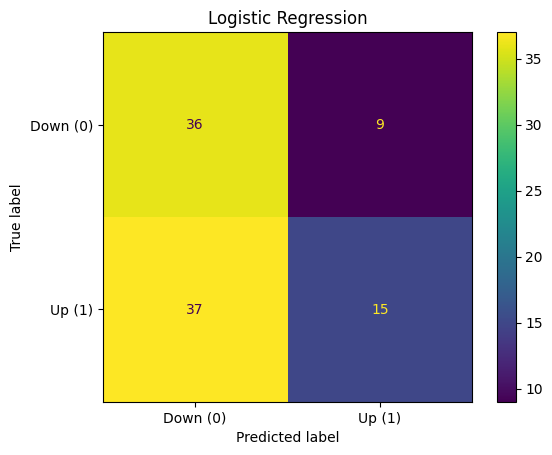

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Logistic Regression")
plt.show()


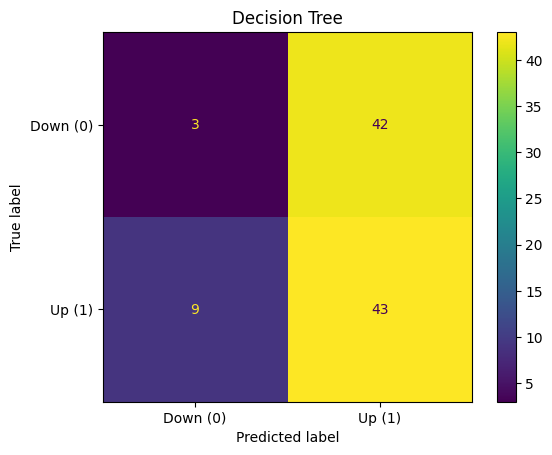

In [76]:
cm = confusion_matrix(y_test, dt_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Decision Tree")
plt.show()

### Observations

#### Logistic Regression

- Correctly predicted **36 Down days** and **15 Up days**.
- Made **37 False Negatives** (actual Up days predicted as Down), which is quite high.
- The model tends to predict **Down** more often than **Up**.
- Overall, it is conservative and misses many upward market movements.

#### Decision Tree

- Correctly predicted **43 Up days** but only **3 Down days**.
- Made **42 False Positives** (actual Down days predicted as Up).
- The model tends to predict **Up** almost all the time.
- This results in many incorrect buy signals and poor overall balance.

#### Comparison

- Logistic Regression is more balanced and makes fewer False Positives.
- Decision Tree captures more Up days but at the cost of many incorrect Up predictions.
- If these predictions were used for trading, the Logistic Regression model would generally be more trustworthy because it avoids many bad trades.
- Neither model is perfect, but Logistic Regression generalises better on this dataset.

## Precision and Recall

Two more metrics that give you a more complete picture:

**Precision** — of all the days the model said 'Up', what fraction actually went Up?
```
Precision = TP / (TP + FP)
```
High precision = fewer false alarms. When the model says 'Up', it's usually right.

**Recall** — of all the actual 'Up' days, what fraction did the model catch?
```
Recall = TP / (TP + FN)
```
High recall = fewer missed opportunities. The model catches most of the good days.

> In trading, you usually care more about precision — you don't want to act on a false alarm and lose money.


In [152]:
from sklearn.metrics import precision_score, recall_score

print('=== Logistic Regression ===')

print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))

print('=== Decision Tree ===')
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall:", recall_score(y_test, dt_predictions))


=== Logistic Regression ===
Precision: 0.625
Recall: 0.28846153846153844
=== Decision Tree ===
Precision: 0.5058823529411764
Recall: 0.8269230769230769


                     Train Accuracy  Test Accuracy
Logistic Regression           55.84          52.58
Decision Tree                 63.64          47.42


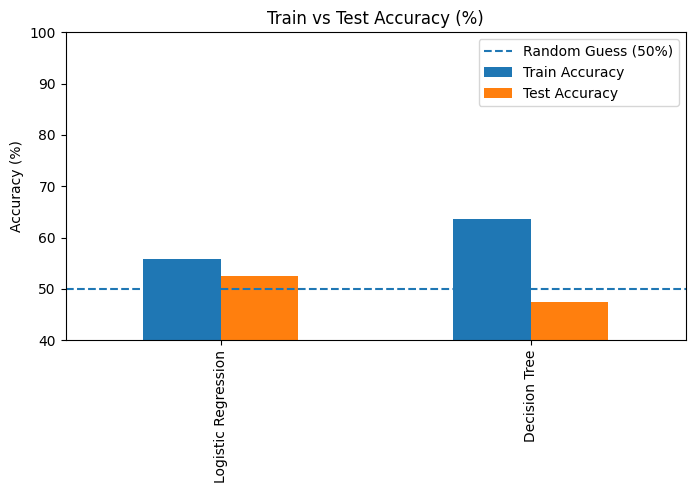

In [153]:
# Side-by-side comparison of both models
results = pd.DataFrame({
    'Train Accuracy': [lr_train_accuracy * 100,
                       dt_train_accuracy * 100],
    'Test Accuracy': [lr_accuracy * 100,
                      dt_accuracy * 100]
}, index=['Logistic Regression', 'Decision Tree'])

print(results.round(2))

results.plot(kind='bar', figsize=(8, 4))

plt.axhline(50, linestyle='--',
            label='Random Guess (50%)')

plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (%)")
plt.ylim(40, 100)

plt.legend()
plt.show()

### Observations

- Logistic Regression achieved similar train (**56%**) and test (**53%**) accuracy, showing good generalisation.
- Its test accuracy is slightly above the **50% baseline**, indicating a small predictive edge.
- Decision Tree achieved higher train accuracy (**64%**) but lower test accuracy (**47%**).
- The large gap between train and test accuracy suggests **overfitting**.
- Overall, Logistic Regression performed better on unseen data.

---
## 7 · Overfitting vs Underfitting

This is one of the most important concepts in all of machine learning.

### Overfitting — The Model Memorised Instead of Learning

Imagine a student who memorises every answer from past exam papers word for word.
They score 100% on practice tests — but when the actual exam has slightly different questions, they fail.

An overfitting model does the same thing:
- **Very high training accuracy** (memorised the training data)
- **Low test accuracy** (can't generalise to new data)

The signal: **Train accuracy >> Test accuracy**

### Underfitting — The Model Didn't Learn Enough

Imagine a student who barely studied and just guesses on every question.
They score poorly on both practice tests and the real exam.

An underfitting model:
- **Low training accuracy**
- **Low test accuracy**
- The model is too simple to capture the patterns in the data

The signal: **Both train and test accuracy are low (near 50% for our problem)**

## The Sweet Spot — Good Generalisation

As model complexity increases, performance usually follows this pattern:

|                    | Underfit | Sweet Spot | Overfit |
|--------------------|-----------|------------|----------|
| **Train Accuracy** | Low | Good | Very High |
| **Test Accuracy**  | Low | Good | Low |


### Let's See Overfitting in Action

We'll train a Decision Tree with **no depth limit** and see what happens:


In [154]:
# A tree with no depth limit will grow until every training row is perfectly classified
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_overfit.fit(X_train, y_train)

overfit_train_acc = accuracy_score(y_train, dt_overfit.predict(X_train))
overfit_test_acc  = accuracy_score(y_test,  dt_overfit.predict(X_test))

print(f'Unlimited Tree — Train Accuracy: {overfit_train_acc:.2%}')
print(f'Unlimited Tree — Test Accuracy : {overfit_test_acc:.2%}')
print()
print('Compare to our max_depth=4 tree:')
print(f'Depth-4 Tree  — Train Accuracy: {dt_train_accuracy:.2%}')
print(f'Depth-4 Tree  — Test Accuracy : {dt_accuracy:.2%}')


Unlimited Tree — Train Accuracy: 100.00%
Unlimited Tree — Test Accuracy : 41.24%

Compare to our max_depth=4 tree:
Depth-4 Tree  — Train Accuracy: 63.64%
Depth-4 Tree  — Test Accuracy : 47.42%


> 🔍 **What you should see:** The unlimited tree gets close to 100% on training data but drops significantly on test data. That's a textbook overfit.
> Our depth=4 tree trades some training accuracy for much better generalisation.


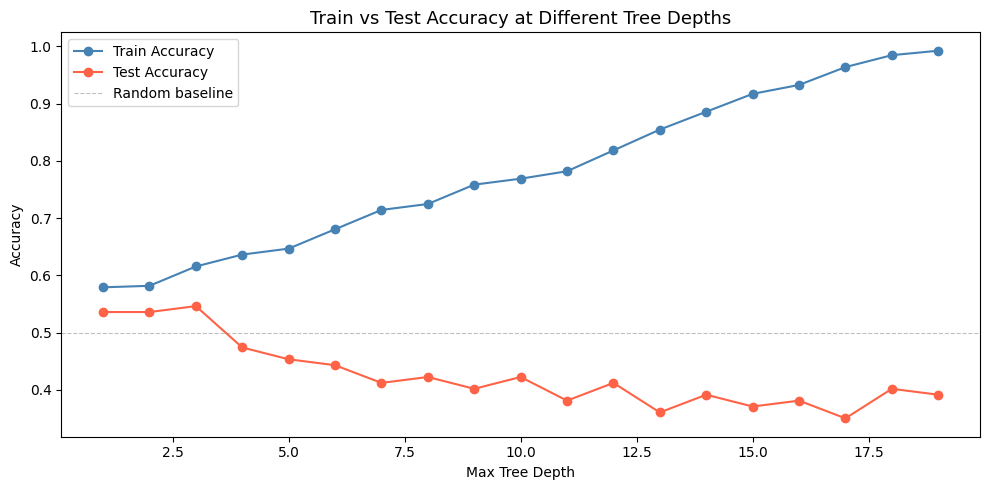

In [155]:
# How does test accuracy change as we increase tree depth?
depths = range(1, 20)
train_scores = []
test_scores  = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o', color='steelblue')
plt.plot(depths, test_scores,  label='Test Accuracy',  marker='o', color='tomato')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random baseline')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Tree Depths', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


> 🔍 **Reading this chart:**
> - Training accuracy keeps climbing as depth increases (memorising more)
> - Test accuracy peaks somewhere in the middle, then drops (overfitting starts)
> - The best depth is wherever test accuracy is highest
> - This is called **hyperparameter tuning** — finding the settings that generalise best

### 📚 Resources

- 🎥 [Bias-Variance Tradeoff — StatQuest](https://www.youtube.com/watch?v=EuBBz3bI-aA)


---
## 8 · Data Leakage — One Final Warning

We covered leakage in Week 3. Now that you're training real models, it becomes even more critical.


The correct approach:
1. Fit (calculate mean/std) only on **X_train**
2. Transform both X_train and X_test using those training statistics

### Quick Leakage Checklist

Before trusting any model's accuracy, ask yourself:

| Check | Question |
|---|---|
| ✅ Features | Do any features use future data? (shift(-1) on anything except Target?) |
| ✅ Split | Did you split by time, not randomly? |
| ✅ Scaling | Did you fit your scaler only on training data? |
| ✅ Target | Is the Target column absent from the feature list? |

> Our current pipeline passes all four checks. ✅




---
## 9 · Which Features Did the Model Think Were Most Useful?

The Decision Tree gives us a built-in way to see which features it relied on most — called **feature importance**.

A higher importance score means the model used that feature more heavily when making decisions.


In [156]:
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)

print(importances.sort_values(ascending=False).round(4))


Price_to_MA20    0.2313
MA5_to_MA20      0.1813
Daily_Return     0.1441
MA5              0.1386
Volatility_5d    0.1365
Volume_Change    0.1008
Lag2_Return      0.0674
Lag1_Return      0.0000
dtype: float64


-> 💡 Features with high importance are the ones the model leaned on most. Features near zero contributed almost nothing.

-> This is useful feedback — if a feature consistently scores near zero, it might not be worth keeping.

->Feature importance does **not** prove a feature causes stock movements. It only tells us which features the Decision Tree used most when making predictions.


---
## Week 4 Summary

Here's what you did this week:

| Step | What you did |
|---|---|
| Loaded data | Read the ML-ready CSV from Week 3 |
| Split data | Train (80%) and Test (20%) — time order preserved |
| Trained Model 1 | Logistic Regression |
| Trained Model 2 | Decision Tree (max_depth=4) |
| Evaluated | Accuracy, confusion matrix, precision, recall |
| Investigated | Overfitting with unlimited depth tree |
| Visualised | Feature importance from Decision Tree |

### Model Results at a Glance


In [157]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=4)', 'Decision Tree (unlimited — overfit)'],
    'Train Acc': [f'{lr_train_accuracy:.1%}', f'{dt_train_accuracy:.1%}', f'{overfit_train_acc:.1%}'],
    'Test Acc':  [f'{lr_accuracy:.1%}',       f'{dt_accuracy:.1%}',       f'{overfit_test_acc:.1%}'],
})
print(summary.to_string(index=False))


                              Model Train Acc Test Acc
                Logistic Regression     55.8%    52.6%
            Decision Tree (depth=4)     63.6%    47.4%
Decision Tree (unlimited — overfit)    100.0%    41.2%


## Week 4 Assignment

Choose a stock other than AAPL.

1. Load the stock's dataset.
2. Add the custom feature you created in Week 3.
3. Train both Logistic Regression and Decision Tree models.
4. Evaluate both models using:
   - Train accuracy
   - Test accuracy
   - Confusion matrix
5. Compare the results to AAPL.

Document 
- Your accuracy results
- The confusion matrices
- A short conclusion on which model and stock performed better.



---
## 📚 Resources for This Week

| Resource | Link |
|---|---|
| 🎥 Logistic Regression explained — StatQuest | [youtube.com/watch?v=yIYKR4sgzI8](https://www.youtube.com/watch?v=yIYKR4sgzI8) |
| 🎥 Decision Trees explained — StatQuest | [youtube.com/watch?v=_L39rN6gz7Y](https://www.youtube.com/watch?v=_L39rN6gz7Y) |
| 🎥 Confusion Matrix explained — StatQuest | [youtube.com/watch?v=Kdsp6soqA7o](https://www.youtube.com/watch?v=Kdsp6soqA7o) |
| 🎥 Overfitting explained — StatQuest | [youtube.com/watch?v=EuBBz3bI-aA](https://www.youtube.com/watch?v=EuBBz3bI-aA) |
| 🎥 Data Leakage — StatQuest | [youtube.com/watch?v=OFGaLUKuHhI](https://www.youtube.com/watch?v=OFGaLUKuHhI) |
| 📖 Scikit-learn — Getting started | [scikit-learn.org/stable/getting_started.html](https://scikit-learn.org/stable/getting_started.html) |
| 📖 Towards Data Science — ML for stock prediction | [towardsdatascience.com/predicting-stock-price-direction](https://towardsdatascience.com/predicting-stock-price-direction-using-machine-learning-18e05d33fd7c) |

---
> 🚀 **See you in Week 5!**
> You've trained your first two real machine learning models. The results might not look spectacular yet — and that's completely normal. Understanding *why* they perform the way they do is more important than chasing high accuracy at this stage. You're building the right foundations.
